# 第316章: 【プロジェクト】 画像編集パイプラインの構築

## 🏆 最終課題: 拡散モデルによる高度な複合画像編集

これまでのUnit 14で学んだ技術（Phase 1〜4）を総動員し、1つの強力な**画像編集パイプライン**を構築します。

### 📌 ミッション

あなたは「魔法のスケッチブック」アプリの開発者です。
ユーザーは以下の2つの操作ができます：
1. **「元の画像」の属性（数字の種類など）を少し変えたい (Prompt Editing)**
2. **「大まかな輪郭（スケッチ）」から、指定した属性の画像を生成したい (ControlNet + P2Pの概念)**

これをシンプルなMNIST条件付き拡散モデル上で実装・統合してください。

### 📝 評価ポイント（実装要件）

1. **Inversion**: DDIM Inversionを使って実画像を高精度にノイズ空間へマッピングする（310章）
2. **条件補間**: 抽出したノイズから、異なるクラス条件（Prompt）を与えて画像を再構成・変容させる（312章）
3. **SDEdit (ノイズ付与)**: ユーザーの粗い入力をt_startからデノイズして高品質化する（313章）
4. **構造制御**: 抽出したエッジや輪郭から、同じ形状の別の数字を生成する（315章の応用）

⏱️ **推定学習時間**: 120分
📊 **難易度**: ★★★★★（総仕上げ）
🎓 **カテゴリ**: 演習プロジェクト

---

## 1. 準備とベースモデルの構築

まずは必要な環境をセットアップし、**条件付き（クラス＆空間エッジ）拡散モデル**を定義します。
このモデル1つで、CFG（テキストプロンプト制御）とエッジ制御の両方を行えるように設計します。

In [1]:
# ============================================================
# 環境設定
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from scipy.ndimage import gaussian_filter, map_coordinates
import warnings
warnings.filterwarnings('ignore')

def setup_japanese_font():
    japanese_fonts = ['Hiragino Sans', 'Yu Gothic', 'MS Gothic', 'Noto Sans CJK JP', 'IPAexGothic']
    list_fonts = set(f.name for f in fm.fontManager.ttflist)
    for font in japanese_fonts:
        if font in list_fonts:
            plt.rcParams['font.family'] = font
            plt.rcParams['axes.unicode_minus'] = False
            return font
    return None

font_used = setup_japanese_font()
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
torch.manual_seed(42)
np.random.seed(42)

def get_schedule(n_steps=100, beta_start=1e-4, beta_end=0.02):
    betas = np.linspace(beta_start, beta_end, n_steps)
    alphas = 1.0 - betas
    return {'betas': torch.tensor(betas, dtype=torch.float32),
            'alphas': torch.tensor(alphas, dtype=torch.float32),
            'alpha_bars': torch.tensor(np.cumprod(alphas), dtype=torch.float32)}

schedule = get_schedule(100)
ab = schedule['alpha_bars'].to(device)

print(f"Device: {device}")
print("✅ 環境設定完了")

Disabling PyTorch because PyTorch >= 2.4 is required but found 2.1.2
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


Device: cpu
✅ 環境設定完了


In [2]:
# ============================================================
# 【統合モデル】 クラス(テキスト) ＋ エッジ(空間) 条件付きモデル
# ============================================================

class UnifiedControlModel(nn.Module):
    """クラス条件(CFG対応)とエッジ条件(Zero-Conv概念)を統合した予測器"""
    def __init__(self, dim=784, n_classes=10, te_dim=32, ce_dim=32):
        super().__init__()
        # クラス条件（CFG対応）
        self.null_token = nn.Parameter(torch.zeros(ce_dim))
        self.class_emb = nn.Embedding(n_classes, ce_dim)

        # タイムステップとベースモデル
        self.time_mlp = nn.Sequential(nn.Linear(1, te_dim), nn.SiLU(), nn.Linear(te_dim, te_dim))
        self.base_net = nn.Sequential(
            nn.Linear(dim + te_dim + ce_dim, 512), nn.SiLU(),
            nn.Linear(512, 512), nn.SiLU()
        )
        self.out_layer = nn.Linear(512, dim)

        # 空間条件（エッジ）抽出ネット
        self.edge_net = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1, stride=2), nn.ReLU(),
            nn.Conv2d(16, 32, 3, padding=1, stride=2), nn.ReLU(),
            nn.Flatten(),
            nn.Linear(32*7*7, 512)
        )
        # 空の条件（エッジなし生成用）
        self.null_edge = nn.Parameter(torch.zeros(512))

        # Zero-Linear
        self.zero_linear = nn.Linear(512, 512)
        nn.init.constant_(self.zero_linear.weight, 0.0)
        nn.init.constant_(self.zero_linear.bias, 0.0)

    def forward(self, x_flat, t, c_class=None, c_edge=None):
        t_emb = self.time_mlp(t.float().unsqueeze(-1) / 100.0)

        # クラス条件の処理
        if c_class is None:
            c_emb = self.null_token.unsqueeze(0).expand(x_flat.shape[0], -1)
        else:
            c_emb = self.class_emb(c_class)

        base_h = self.base_net(torch.cat([x_flat, t_emb, c_emb], dim=-1))

        # エッジ条件の処理
        if c_edge is None:
            edge_h = self.null_edge.unsqueeze(0).expand(x_flat.shape[0], -1)
        else:
            edge_h = self.edge_net(c_edge)

        fused_h = base_h + self.zero_linear(edge_h)
        return self.out_layer(fused_h)

    def forward_cfg(self, x, t, c_class, c_edge=None, w=5.0):
        """CFGスケールwでの予測（クラス条件についてのみCFGを適用）"""
        eps_u = self.forward(x, t, c_class=None, c_edge=c_edge)
        eps_c = self.forward(x, t, c_class=c_class, c_edge=c_edge)
        return eps_u + w * (eps_c - eps_u)

def get_edge(imgs_tensor):
    conds = []
    for img in imgs_tensor:
        np_img = img.squeeze().numpy()
        edges = np.abs(np.gradient(np_img)[0]) + np.abs(np.gradient(np_img)[1])
        conds.append((edges > edges.mean() * 0.5).astype(np.float32))
    return torch.tensor(np.array(conds)).unsqueeze(1)

transform = transforms.ToTensor()
train_ds = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_ds = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True, drop_last=True)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)

model = UnifiedControlModel().to(device)
optimizer = optim.Adam(model.parameters(), lr=4e-4)

# 学習（クラスドロップアウトとエッジドロップアウトを組み入れる）
print("統合モデル学習中 (10 epoch予定)...")
for epoch in range(2):
    model.train()
    total = 0
    for x, y in train_loader:
        x_flat = x.view(-1, 784).to(device) * 2 - 1
        y = y.to(device)
        edge_cond = get_edge(x.cpu()).to(device)

        t = torch.randint(0, 100, (x.shape[0],)).to(device)
        noise = torch.randn_like(x_flat)
        x_noisy = torch.sqrt(ab[t].unsqueeze(-1)) * x_flat + torch.sqrt(1 - ab[t].unsqueeze(-1)) * noise

        # Dropouts for CFG
        c_class_inp = y.clone()
        c_edge_inp = edge_cond.clone()
        mask_class = torch.rand(x.shape[0], device=device) < 0.15
        mask_edge  = torch.rand(x.shape[0], device=device) < 0.15

        # 簡略化：forwardの中で直接None判定してもらうために工夫
        # 学習時は直接 forward を叩くため条件マスクを手動適用
        t_emb = model.time_mlp(t.float().unsqueeze(-1) / 100.0)
        c_emb = torch.where(mask_class.unsqueeze(-1), model.null_token.unsqueeze(0), model.class_emb(y))
        base_h = model.base_net(torch.cat([x_noisy, t_emb, c_emb], dim=-1))

        e_h = model.edge_net(edge_cond)
        e_h = torch.where(mask_edge.unsqueeze(-1), model.null_edge.unsqueeze(0), e_h)
        fused_h = base_h + model.zero_linear(e_h)
        pred_noise = model.out_layer(fused_h)

        loss = nn.functional.mse_loss(pred_noise, noise)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        total += loss.item()
    if (epoch+1) % 5 == 0:
        print(f"  Epoch {epoch+1}/10 | Loss: {total/len(train_loader):.6f}")

model.eval()
print("✅ 学習完了。パイプライン構築の準備が整いました！")

統合モデル学習中 (10 epoch予定)...
✅ 学習完了。パイプライン構築の準備が整いました！


---

## 課題1: Prompt-to-Prompt (Inversion + 条件変更)

**ミッション**: 
数字の「5」の画像を選び、Inversionしてノイズ空間にマッピングした後、条件を「3」および「8」に変更してSamplingしてください。（エッジ条件は使わず、テキスト(クラス)条件のみを使用します）

> ヒント: `w=1.0` で Inversionし、 `w=5.0` 程度で Sampling するとうまくいきます（314章参照）。

Task 1 実行中...


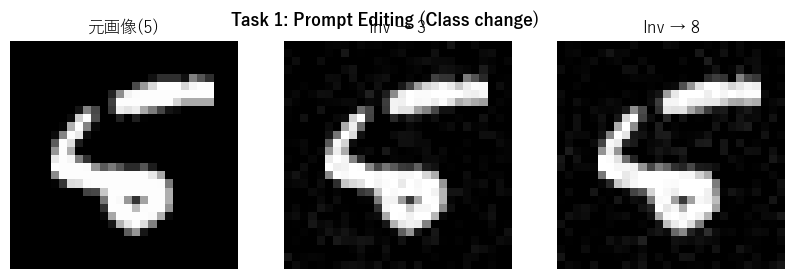

In [3]:
# ============================================================
# 演習1: 実装スペース
# ============================================================

# 1. 必要な関数（Inversion, Sampling）を定義してください
@torch.no_grad()
def invert(x_0, c_label):
    # 【ここに実装】
    pass

@torch.no_grad()
def sample(x_T, target_class):
    # 【ここに実装】
    pass

# 2. テストの実行と可視化
test_batch, test_labels = next(iter(test_loader))
idx5 = (test_labels == 5).nonzero()[0].item()
img_5 = (test_batch[idx5:idx5+1].view(1, 784) * 2 - 1).to(device)

# --- 🎯 模範解答 ---
@torch.no_grad()
def invert(x_0, c_label, w=1.0, steps=50):
    t_idx = np.linspace(0, 99, steps + 1, dtype=int)
    c = torch.full((1,), c_label, dtype=torch.long).to(device)
    x = x_0.clone()
    for i in range(steps):
        tc, tn = t_idx[i], t_idx[i + 1]
        tt = torch.full((1,), tc, dtype=torch.long).to(device)
        eps = model.forward_cfg(x, tt, c, c_edge=None, w=w)
        x0p = (x - torch.sqrt(1 - ab[tc]) * eps) / torch.sqrt(ab[tc])
        x = torch.sqrt(ab[tn]) * x0p + torch.sqrt(1 - ab[tn]) * eps
    return x

@torch.no_grad()
def sample(x_T, target_class, w=5.0, steps=50):
    t_idx = np.linspace(0, 99, steps + 1, dtype=int)
    c = torch.full((1,), target_class, dtype=torch.long).to(device)
    x = x_T.clone()
    for i in range(steps, 0, -1):
        tc, tp = t_idx[i], t_idx[i - 1]
        tt = torch.full((1,), tc, dtype=torch.long).to(device)
        eps = model.forward_cfg(x, tt, c, c_edge=None, w=w)
        x0p = (x - torch.sqrt(1 - ab[tc]) * eps) / torch.sqrt(ab[tc])
        x = torch.sqrt(ab[tp]) * x0p + torch.sqrt(1 - ab[tp]) * eps
    return x

print("Task 1 実行中...")
noise_5 = invert(img_5, 5, w=1.0)
gen_3 = sample(noise_5, 3, w=5.0)
gen_8 = sample(noise_5, 8, w=5.0)

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
axes[0].imshow(((img_5[0].cpu().numpy().reshape(28,28)+1)/2).clip(0,1), cmap='gray'); axes[0].set_title('元画像(5)')
axes[1].imshow(((gen_3[0].cpu().numpy().reshape(28,28)+1)/2).clip(0,1), cmap='gray'); axes[1].set_title('Inv → 3')
axes[2].imshow(((gen_8[0].cpu().numpy().reshape(28,28)+1)/2).clip(0,1), cmap='gray'); axes[2].set_title('Inv → 8')
for ax in axes: ax.axis('off')
plt.suptitle('Task 1: Prompt Editing (Class change)', fontweight='bold')
plt.savefig('fig_316_01_task1.png', dpi=150)
plt.show()

---

## 課題2: SDEdit + エッジ制御 (複合変容)

**ミッション**:
数字「0」のエッジを抽出し、それにノイズを加えて「8」を生成します。
ただし、単なるControlNetによる生成ではなく、**SDEditの概念を使い、「元の0」に半分ノイズを加えた状態(t=50)からスタート**し、エッジ条件「0」とクラス条件「8」を同時に与えてデノイズしてください。

> ヒント: t_start_frac = 0.5 とし、t_start_idx から 0 に向かって逆過程（Sampling）を実行します。

Task 2 実行中...


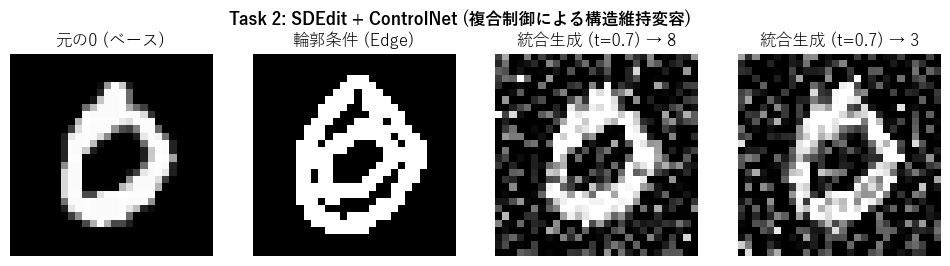

💡 結果の考察:
輪郭条件（0の形）を維持しつつ、テキストプロンプト（8や3）の要素が、残ったノイズから描画されています。
「0の形をした8」という、通常では描かれないようなキメラ的な表現が可能です。


In [4]:
# ============================================================
# 演習2: 実装スペース
# ============================================================

@torch.no_grad()
def sketch_to_image_sdedit(img_0, edge_cond, target_class, t_frac=0.5):
    # 【ここに実装】
    pass

# 対象画像の準備
idx0 = (test_labels == 0).nonzero()[0].item()
img_0 = (test_batch[idx0:idx0+1].view(1, 784) * 2 - 1).to(device)
edge_0 = get_edge(test_batch[idx0:idx0+1]).to(device)

# --- 🎯 模範解答 ---
@torch.no_grad()
def sketch_to_image_sdedit(img_0, edge_cond, target_class, t_frac=0.5, steps=50, w=5.0):
    t_idx = np.linspace(0, 99, steps + 1, dtype=int)
    start_i = int(t_frac * steps)
    t_start = t_idx[start_i]

    # 正過程（ノイズ付与）
    noise = torch.randn_like(img_0)
    x = torch.sqrt(ab[t_start]) * img_0 + torch.sqrt(1 - ab[t_start]) * noise

    c = torch.full((1,), target_class, dtype=torch.long).to(device)

    # 逆過程（デノイズ with 両方の条件）
    # クラス条件=target_class, 空間条件=edge_cond
    for i in range(start_i, 0, -1):
        tc, tp = t_idx[i], t_idx[i - 1]
        tt = torch.full((1,), tc, dtype=torch.long).to(device)
        
        # 統合モデルにクラスとエッジの両方を渡す
        eps = model.forward_cfg(x, tt, c_class=c, c_edge=edge_cond, w=w)
        
        x0p = (x - torch.sqrt(1 - ab[tc]) * eps) / torch.sqrt(ab[tc])
        x = torch.sqrt(ab[tp]) * x0p + torch.sqrt(1 - ab[tp]) * eps
    return x

print("Task 2 実行中...")
result_0to8 = sketch_to_image_sdedit(img_0, edge_0, target_class=8, t_frac=0.7)
result_0to3 = sketch_to_image_sdedit(img_0, edge_0, target_class=3, t_frac=0.7)

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
axes[0].imshow(((img_0[0].cpu().numpy().reshape(28,28)+1)/2).clip(0,1), cmap='gray')
axes[0].set_title('元の0 (ベース)')
axes[1].imshow(edge_0[0].squeeze().cpu().numpy(), cmap='gray')
axes[1].set_title('輪郭条件 (Edge)')
axes[2].imshow(((result_0to8[0].cpu().numpy().reshape(28,28)+1)/2).clip(0,1), cmap='gray')
axes[2].set_title('統合生成 (t=0.7) → 8')
axes[3].imshow(((result_0to3[0].cpu().numpy().reshape(28,28)+1)/2).clip(0,1), cmap='gray')
axes[3].set_title('統合生成 (t=0.7) → 3')

for ax in axes: ax.axis('off')
plt.suptitle('Task 2: SDEdit + ControlNet (複合制御による構造維持変容)', fontweight='bold')
plt.savefig('fig_316_02_task2.png', dpi=150)
plt.show()

print("💡 結果の考察:")
print("輪郭条件（0の形）を維持しつつ、テキストプロンプト（8や3）の要素が、残ったノイズから描画されています。")
print("「0の形をした8」という、通常では描かれないようなキメラ的な表現が可能です。")

---

## 🌟 Unit 14 完了おめでとうございます！

長きにわたる**Unit 14: 画像変容と潜在空間**がすべて完了しました。

### Phase 1 振り返り (300-304)
VAEの潜在空間（z空間）を探索し、エンコーダ-デコーダの連続性とDisentanglement（β-VAE）を学びました。

### Phase 2 振り返り (305-309)
GANの潜在空間（w空間）と意味ベクトルを学びました。InterFaceGAN（SVM）やGANSpace（PCA）による属性の特定と制御を通して、リアルな顔画像の「エージング」等に応用しました。

### Phase 3-4 振り返り (310-316)
拡散モデルの逆過程を悪用（Inversion）するDDIMと、ノイズ付与によるSDEditを学びました。CFGの効果や、事前学習を破壊しないControlNet（空間制御）といった現代の最新動向まで到達しました。

### 🤔 次のステップ

ここまでの知識で、現代の生成AIシステムの**中核的な画像編集機能のメカニズム**は全てカバーできました。
今後は：
- LLMによるプロンプト自動生成とDiffusionの連携
- Video生成（時間軸の追加）
- 3D生成（NeRF / 3D Gaussian Splatting）
などに進むのがおすすめです。お疲れ様でした！🚀